In [152]:
#drive mount
from google.colab import drive
drive.mount('/content/drive', force_remount= True)
origin = ('/content/drive/MyDrive/새싹과정/my/4주차/모의 대회용 데이터 (병원 개 폐업)')


test_df = pd.read_csv(os.path.join(origin, 'test.csv'))
train_df = pd.read_csv(os.path.join(origin, 'train.csv'))
submit_sample = pd.read_csv(os.path.join(origin, 'submission_sample.csv'))

Mounted at /content/drive


In [153]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#RandomForest : 과적합이 많지만 아무 데이터에나 잘 적용
#SVC : 원리를 설명하기는 힘들지만 아무 데이터에나 잘 적용
#xgb, lgb : 부스팅계열 알고리즘으로 성능이 잘 나옴
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb

# 순서

 흐름도 짜보기!!

1. 데이터 구성 확인
    - info, describe, shape, columns
2. 결측치, 이상치 확인
    - 결측치
    - 이상치:
     - 이상치 확인 함수 or IQR
3. 전처리
    - 평균, max, min 등 대치
    - mode 대치
    - drop(데이터 손실 우려)
4. 인코딩
    - 프리퀀시, 라벨, 등등 쓰이는 의미에 적합하게 선택하기
    - 라벨: 등급을 수치로 살리기
    - 원핫: 우열 없는 것(순수 범주)
    - 빈도 (프리):판단하기(최빈..)
5. 모델링

6. 제출

# 1. 데이터 구성 확인

In [71]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 58 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   inst_id             301 non-null    int64  
 1   OC                  301 non-null    object 
 2   sido                301 non-null    object 
 3   sgg                 301 non-null    int64  
 4   openDate            301 non-null    int64  
 5   bedCount            296 non-null    float64
 6   instkind            300 non-null    object 
 7   revenue1            293 non-null    float64
 8   salescost1          293 non-null    float64
 9   sga1                293 non-null    float64
 10  salary1             293 non-null    float64
 11  noi1                293 non-null    float64
 12  noe1                293 non-null    float64
 13  interest1           293 non-null    float64
 14  ctax1               293 non-null    float64
 15  profit1             293 non-null    float64
 16  liquidAs

In [72]:
train_df.describe()

,inst_id,sgg,openDate,bedCount,revenue1,salescost1,sga1,salary1,noi1,noe1,interest1,ctax1,profit1,liquidAsset1,quickAsset1,receivableS1,inventoryAsset1,nonCAsset1,tanAsset1,OnonCAsset1,receivableL1,debt1,liquidLiabilities1,shortLoan1,NCLiabilities1,longLoan1,netAsset1,surplus1,revenue2,salescost2,sga2,salary2,noi2,noe2,interest2,ctax2,profit2,liquidAsset2,quickAsset2,receivableS2,inventoryAsset2,nonCAsset2,tanAsset2,OnonCAsset2,receivableL2,debt2,liquidLiabilities2,shortLoan2,NCLiabilities2,longLoan2,netAsset2,surplus2,employee1,employee2
count,301.000000,301.000000,3.010000e+02,296.000000,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,2.930000e+02,291.000000,288.000000
mean,219.056478,81.039867,2.005013e+07,145.709459,1.288175e+10,2.014903e+09,1.033244e+10,5.654115e+09,2.696151e+08,5.115870e+08,1.868966e+08,7.847322e+07,2.101700e+08,3.536587e+09,3.414762e+09,6.975862e+08,1.154533e+08,1.140673e+10,1.053408e+10,3.406503e+08,2.516802e+05,8.765310e+09,4.352925e+09,1.758237e+09,4.583473e+09,2.646564e+09,5.938213e+09,1.265935e+09,1.170905e+10,1.842095e+09,9.203487e+09,5.023230e+09,2.223813e+08,5.617669e+08,1.736360e+08,6.832259e+07,2.563439e+08,3.222852e+09,3.106104e+09,6.103070e+08,1.063667e+08,1.045214e+10,9.651555e+09,3.232921e+08,2.226700e+05,8.146026e+09,3.860584e+09,1.510050e+09,4.471247e+09,2.709979e+09,5.273919e+09,9.786279e+08,142.546392,134.326389
std,121.234869,50.969714,8.893815e+04,118.923890,2.043543e+10,7.460271e+09,1.493886e+10,8.083343e+09,8.023701e+08,1.060379e+09,2.738658e+08,2.486102e+08,1.134673e+09,6.285995e+09,6.093581e+09,1.455332e+09,2.551702e+08,1.710516e+10,1.574525e+10,9.359381e+08,4.308072e+06,1.286112e+10,6.474262e+09,3.194540e+09,7.847530e+09,4.697523e+09,1.266035e+10,8.248321e+09,1.894998e+10,6.744178e+09,1.352567e+10,7.406530e+09,5.274637e+08,1.121856e+09,2.693894e+08,2.428512e+08,1.111963e+09,6.015755e+09,5.823176e+09,1.455249e+09,2.490099e+08,1.649538e+10,1.521792e+10,8.784355e+08,3.811496e+06,1.255800e+10,6.797242e+09,2.953412e+09,7.659580e+09,4.564001e+09,1.081259e+10,4.688798e+09,160.191073,151.061786
min,1.000000,1.000000,1.978012e+07,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.696701e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.019624e+10,-2.914970e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.064823e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.014780e+10,-2.781507e+09,0.000000,0.000000
25%,112.000000,37.000000,2.001102e+07,52.750000,3.252112e+09,0.000000e+00,2.758201e+09,1.626053e+09,8.217133e+06,8.013395e+07,5.066474e+07,0.000000e+00,-2.168279e+06,7.199253e+08,6.806512e+08,0.000000e+00,4.177116e+06,2.900012e+09,2.700124e+09,9.680000e+05,0.000000e+00,1.953077e+09,5.110121e+08,0.000000e+00,4.285000e+08,0.000000e+00,1.224795e+09,0.000000e+00,2.731342e+09,0.000000e+00,2.253260e+09,1.347918e+09,6.453360e+06,6.473168e+07,3.142969e+07,0.000000e+00,0.000000e+00,4.703623e+08,4.526867e+08,0.000000e+00,2.054789e+06,2.479446e+09,2.338407e+09,0.000000e+00,0.000000e+00,1.283220e+09,2.855741e+08,0.000000e+00,2.557878e+07,0.000000e+00,1.017573e+09,0.000000e+00,5

1. 데이터 스케일링 범위 확인
-> 범위가 다른값 : 정규화 처리가 안됨
2. 'opendate' 형변환
-> 개업일자로부터 얼마나 되었는가? (base time)
---



In [10]:
train_df.shape

(301, 58)

-> X 특징 58개, 차원축소 ㄱㄱ

feature_importance (중요도 높은 순으로 가져오기)

# 결측치 확인

In [8]:
# 결측치 어떻게 메꿀래?
train_df.isnull().sum()

,0
inst_id,0
OC,0
sido,0
sgg,0
openDate,0
bedCount,5
instkind,1
revenue1,8
salescost1,8
sga1,8


In [11]:
# => 참고: 대회 페이지 '코드공유' 살펴보기

In [154]:
#이상치 확인
#박스플롯 활용 -> 숫자로 된 열만 가능,

# 1.숫자로 된 컬럼만 필터
# 카피를 뜨자
# 카피를 뜨고 숫자로 된 컬럼만 분리해서 가져올까
t_df = train_df.copy()
draw_target=list(t_df.dtypes[t_df.dtypes != 'object'].index)

#위의 조건의 결과인 리스트가 필요함(list로 묶고 변수 할당)
#.index: 인덱스
#(t_df.columns.dtype ='object')를 드롭? -> 데이터 손실 우려 후순위로 두는게 좋을듯


# 2. 그 열을 사용해서 그림

#x,y가 뭔디???????
#sns.boxpot(data = t_df, x = box_x,    )

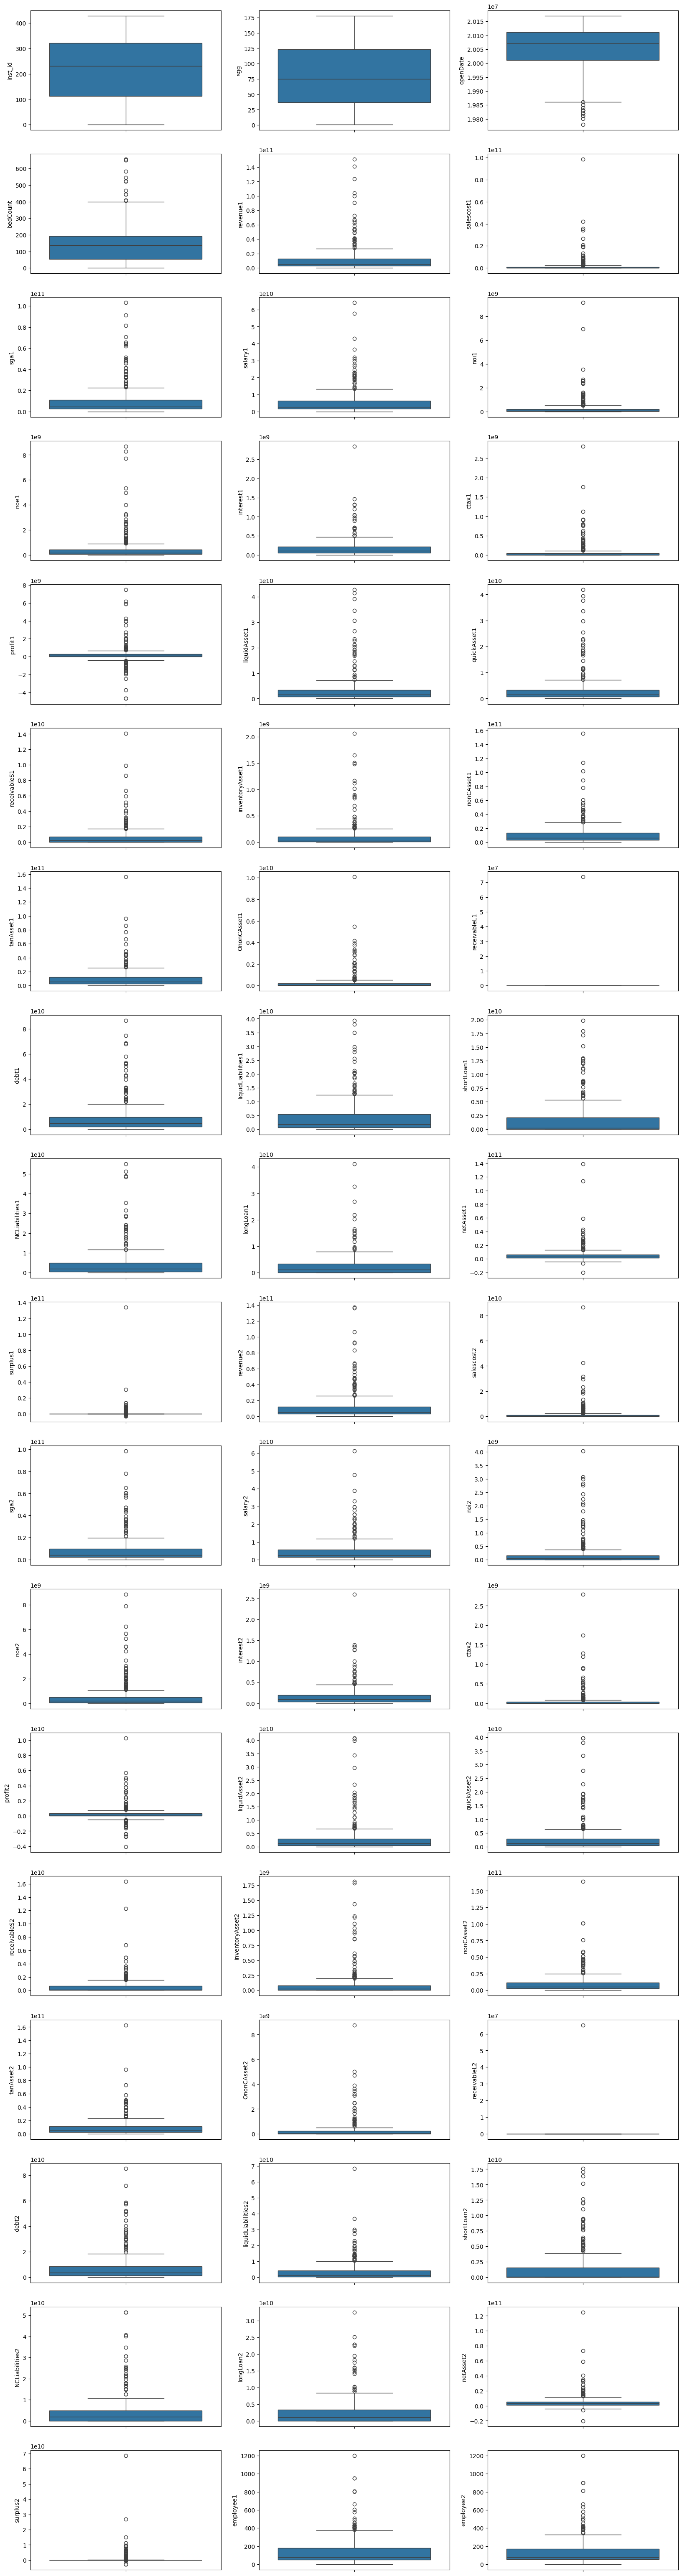

In [25]:
# 2. 그 열을 사용해서 그림
#plt.subplot(총 행의 개수, 총 열의 개수, 이번에 그릴 그래프 위치(i+1))

#plt.subplot(2,4,i)

plt.figure(figsize = (20,84))

for i, col in enumerate(draw_target):
    plt.subplot(len(draw_target)// 3+1, 3, i+1)         #plt는 1부터 카운트,  i+1
                                                        #3+1: 3으로 나누고 몫에 1을 더한 꼴
    sns.boxplot(y=t_df[col])        #열에 대한 것이라 x가 불필요

In [155]:
#X,Y split
Y = t_df['OC']
X = t_df.drop(columns = ['OC'])

In [93]:
X.head()

,inst_id,sido,sgg,openDate,bedCount,instkind,revenue1,salescost1,sga1,salary1,noi1,noe1,interest1,ctax1,profit1,liquidAsset1,quickAsset1,receivableS1,inventoryAsset1,nonCAsset1,tanAsset1,OnonCAsset1,receivableL1,debt1,liquidLiabilities1,shortLoan1,NCLiabilities1,longLoan1,netAsset1,surplus1,revenue2,salescost2,sga2,salary2,noi2,noe2,interest2,ctax2,profit2,liquidAsset2,quickAsset2,receivableS2,inventoryAsset2,nonCAsset2,tanAsset2,OnonCAsset2,receivableL2,debt2,liquidLiabilities2,shortLoan2,NCLiabilities2,longLoan2,netAsset2,surplus2,employee1,employee2,ownerChange
0,1,choongnam,73,20071228,175.0,nursing_hospital,4.217530e+09,0.0,3.961135e+09,2.033835e+09,15652441.0,1.523624e+07,1.323624e+07,31641798.0,225169678.0,1.012700e+09,9.976719e+08,4.700557e+08,1.502781e+07,2.514586e+09,2.360684e+09,1.434496e+08,0.0,6.828260e+08,2.013237e+08,0.000000e+00,4.815023e+08,3.510000e+08,2.844460e+09,1.496394e+09,4.297848e+09,0.0,4.057422e+09,2.063787e+09,16194675.0,2.998335e+07,1.568305e+07,18808074.0,207829685.0,8.301695e+08,8.165705e+08,5.237026e+08,1.359897e+07,2.548115e+09,2.386263e+09,1.458986e+08,0.0,7.589937e+08,2.228769e+08,0.000000e+00,5.361169e+08,3.900000e+08,2.619290e+09,1.271224e+09,62.0,64.0,same
1,3,gyeongnam,32,19970401,410.0,general_hospital,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,801.0,813.0,same
2,4,gyeonggi,89,20161228,468.0,nursing_hospital,1.004522e+09,515483669.0,4.472197e+08,2.964023e+08,76156.0,3.000000e+04,0.000000e+00,0.0,41864754.0,2.724421e+08,2.536822e+08,8.095950e+06,1.875997e+07,1.204810e+08,1.204810e+08,0.000000e+00,0.0,9.241434e+07,9.241434e+07,0.000000e+00,0.000000e+00,0.000000e+00,3.005088e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,234.0,1.0,same
3,7,incheon,141,20000814,353.0,general_hospital,7.250734e+10,0.0,7.067740e+10,3.178605e+10,506223059.0,1.259568e+09,1.196881e+09,173769780.0,902830288.0,1.304154e+10,1.153475e+10,0.000000e+00,1.506793e+09,4.317936e+10,3.832078e+10,3.945208e+09,0.0,4.236380e+10,2.799188e+10,1.988520e+10,1.437192e+10,7.253040e+09,1.385710e+10,8.643659e+09,6.685834e+10,0.0,6.492419e+10,2.971135e+10,476807804.0,1.353672e+09,1.277422e+09,218891720.0,838387466.0,1.112572e+10,9.890540e+09,0.000000e+00,1.235181e+09,3.958356e+10,3.485576e+10,3.915906e+09,0.0,3.775501e+10,1.701860e+10,9.219427e+09,2.073641e+10,1.510000e+10,1.295427e+10,7.740829e+09,663.0,663.0,same
4,9,gyeongnam,32,20050901,196.0,general_hospital,4.904354e+10,0.0,4.765605e+10,2.446078e+10,112352259.0,1.419089e+09,1.307249e+09,0.0,80749696.0,6.317084e+09,5.873265e+09,4.099320e+09,4.438186e+08,4.366733e+10,4.330613e+10,2.223400e+08,0.0,4.989811e+10,2.890919e+10,1.793038e+10,2.098892e+10,1.350000e+10,8.631164e+07,9.025550e+09,4.808280e+10,0.0,4.712580e+10,2.346004e+10,597748128.0,1.522108e+09,1.349851e+09,0.0,32642585.0,4.906776e+09,4.464017e+09,3.365227e+09,4.427591e+08,4.653138e+10,4.562945e+10,7.893407e+08,0.0,5.143259e+10,3.007259e+10,1.759375e+10,2.136001e+10,1.410803e+10,5.561941e+06,9.025550e+09,206.0,197.0,same


In [94]:
Y.head()

,OC
0,open
1,open
2,open
3,open
4,open


# 인코딩

- X 인코딩 진행:
- Y 인코딩 진행: open 1, close 0 -> replace 진행

In [79]:
# Y 인코딩

Y = Y.replace({'open':1, 'close':0})
Y.head()

,OC
0,1
1,1
2,1
3,1
4,1


In [161]:
#X 인코딩
# 숫자 / 문자

numeric_target = []
string_target = []

for i in X.columns:
    if X[i].dtypes != 'object':
        numeric_target.append(i)
    else:
        string_target.append(i)

In [162]:
X[string_target]

,sido,instkind,ownerChange
0,choongnam,nursing_hospital,same
1,gyeongnam,general_hospital,same
2,gyeonggi,nursing_hospital,same
3,incheon,general_hospital,same
4,gyeongnam,general_hospital,same
...,...,...,...
296,jeonnam,nursing_hospital,same
297,choongnam,hospital,same
298,gyeongbuk,hospital,NaN
299,gyeonggi,nursing_hospital,NaN


In [163]:
#sido : 유니크 찍어보고 바이너리, 프리퀀시.. 적합한 것 결정

#sido, instkind, ownerchange -> for 문으로 각각 라벨 인코딩 처리

for column in string_target:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])

In [164]:
X.fillna(0, inplace =True)

In [165]:
X.head()

,inst_id,sido,sgg,openDate,bedCount,instkind,revenue1,salescost1,sga1,salary1,noi1,noe1,interest1,ctax1,profit1,liquidAsset1,quickAsset1,receivableS1,inventoryAsset1,nonCAsset1,tanAsset1,OnonCAsset1,receivableL1,debt1,liquidLiabilities1,shortLoan1,NCLiabilities1,longLoan1,netAsset1,surplus1,revenue2,salescost2,sga2,salary2,noi2,noe2,interest2,ctax2,profit2,liquidAsset2,quickAsset2,receivableS2,inventoryAsset2,nonCAsset2,tanAsset2,OnonCAsset2,receivableL2,debt2,liquidLiabilities2,shortLoan2,NCLiabilities2,longLoan2,netAsset2,surplus2,employee1,employee2,ownerChange
0,1,2,73,20071228,175.0,4,4.217530e+09,0.0,3.961135e+09,2.033835e+09,15652441.0,1.523624e+07,1.323624e+07,31641798.0,225169678.0,1.012700e+09,9.976719e+08,4.700557e+08,1.502781e+07,2.514586e+09,2.360684e+09,1.434496e+08,0.0,6.828260e+08,2.013237e+08,0.000000e+00,4.815023e+08,3.510000e+08,2.844460e+09,1.496394e+09,4.297848e+09,0.0,4.057422e+09,2.063787e+09,16194675.0,2.998335e+07,1.568305e+07,18808074.0,207829685.0,8.301695e+08,8.165705e+08,5.237026e+08,1.359897e+07,2.548115e+09,2.386263e+09,1.458986e+08,0.0,7.589937e+08,2.228769e+08,0.000000e+00,5.361169e+08,3.900000e+08,2.619290e+09,1.271224e+09,62.0,64.0,1
1,3,9,32,19970401,410.0,2,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,801.0,813.0,1
2,4,8,89,20161228,468.0,4,1.004522e+09,515483669.0,4.472197e+08,2.964023e+08,76156.0,3.000000e+04,0.000000e+00,0.0,41864754.0,2.724421e+08,2.536822e+08,8.095950e+06,1.875997e+07,1.204810e+08,1.204810e+08,0.000000e+00,0.0,9.241434e+07,9.241434e+07,0.000000e+00,0.000000e+00,0.000000e+00,3.005088e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,234.0,1.0,1
3,7,10,141,20000814,353.0,2,7.250734e+10,0.0,7.067740e+10,3.178605e+10,506223059.0,1.259568e+09,1.196881e+09,173769780.0,902830288.0,1.304154e+10,1.153475e+10,0.000000e+00,1.506793e+09,4.317936e+10,3.832078e+10,3.945208e+09,0.0,4.236380e+10,2.799188e+10,1.988520e+10,1.437192e+10,7.253040e+09,1.385710e+10,8.643659e+09,6.685834e+10,0.0,6.492419e+10,2.971135e+10,476807804.0,1.353672e+09,1.277422e+09,218891720.0,838387466.0,1.112572e+10,9.890540e+09,0.000000e+00,1.235181e+09,3.958356e+10,3.485576e+10,3.915906e+09,0.0,3.775501e+10,1.701860e+10,9.219427e+09,2.073641e+10,1.510000e+10,1.295427e+10,7.740829e+09,663.0,663.0,1
4,9,9,32,20050901,196.0,2,4.904354e+10,0.0,4.765605e+10,2.446078e+10,112352259.0,1.419089e+09,1.307249e+09,0.0,80749696.0,6.317084e+09,5.873265e+09,4.099320e+09,4.438186e+08,4.366733e+10,4.330613e+10,2.223400e+08,0.0,4.989811e+10,2.890919e+10,1.793038e+10,2.098892e+10,1.350000e+10,8.631164e+07,9.025550e+09,4.808280e+10,0.0,4.712580e+10,2.346004e+10,597748128.0,1.522108e+09,1.349851e+09,0.0,32642585.0,4.906776e+09,4.464017e+09,3.365227e+09,4.427591e+08,4.653138e+10,4.562945e+10,7.893407e+08,0.0,5.143259e+10,3.007259e+10,1.759375e+10,2.136001e+10,1.410803e+10,5.561941e+06,9.025550e+09,206.0,197.0,1


# 모델링

In [157]:
X['employee1']= X['employee1'].astype('float')
X['employee2'] = X['employee2'].astype('float')
#Y['OC']= Y['OC'].astype('str').str.replace(" ","")
Y['OC'] = train_df['OC'].replace({'open':1, 'close': 0})

Y.isnull().sum()

/tmp/ipykernel_2006/3622000536.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y['OC'] = train_df['OC'].replace({'open':1, 'close': 0})


np.int64(0)

In [158]:
Y['OC'] = Y['OC'].replace({'open':1, ' close': 0})

/tmp/ipykernel_2006/3963931211.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y['OC'] = Y['OC'].replace({'open':1, ' close': 0})


In [159]:
Y = Y['OC']

In [160]:
Y

,OC
0,1
1,1
2,1
3,1
4,1
...,...
296,1
297,0
298,0
299,0


In [166]:
#X, Y에 존재하는 숫자 데이터를 float으로 만들어 머신러닝에 들어갈 수 있도록 정리
for i in X.columns:
    X[i] = X[i].astype(float)

Y = Y.astype(float)

In [167]:
#rf 훈련

RF = RandomForestClassifier(n_estimators=50)
RF.fit(X,Y)

RandomForestClassifier(n_estimators=50)

# Train에 했던 전처리 재진행
= Train에 썼던 인코더를 그대로 test에 적용해야함
따라서 새로운 인코더 객체 생성 X

In [168]:
string_target = []
for i in train_df.columns:
    if train_df[i].dtypes == 'object':
        string_target.append(i)

In [169]:
string_target

['OC', 'sido', 'instkind', 'ownerChange']

In [170]:
print( train_df['sido'].unique() )
print( test_df['sido'].unique()  )

['choongnam' 'gyeongnam' 'gyeonggi' 'incheon' 'busan' 'jeonnam' 'seoul'
 'jeonbuk' 'choongbuk' 'ulsan' 'daejeon' 'daegu' 'gyeongbuk' 'gangwon'
 'gwangju' 'sejong']
['incheon' 'jeju' 'jeonnam' 'busan' 'jeonbuk' 'gyeonggi' 'gyeongbuk'
 'daejeon' 'seoul' 'daegu' 'choongbuk' 'ulsan' 'gyeongnam' 'choongnam'
 'sejong']


In [171]:
from sklearn.preprocessing import OrdinalEncoder


string_target.remove('OC')

for column in string_target:
    #새로운 라벨 인코더를 정의
    #train에서 인코딩할 때 없었던 'jeju'라는 새로운 데이터 입력
    #새로운 데이터가 들어오면 -1로 처리해줘.
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    #'그 열' => column // 그 열을 le.fit_transform하고, 그 결과를 train_df
    train_df[column] = oe.fit_transform(train_df[[column]])
    test_df[column] = oe.transform(test_df[[column]])

In [172]:
#결측치 메꾸기
train_df.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)

In [173]:
from sklearn.ensemble import RandomForestClassifier
Y = train_df['OC']
Y = Y.replace({'open': 1, 'close': 0, ' close':0})
X = train_df.drop(columns = ['OC'])

RF = RandomForestClassifier(n_estimators=50)
RF.fit(X,Y)

/tmp/ipykernel_2006/3125986690.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({'open': 1, 'close': 0, ' close':0})


RandomForestClassifier(n_estimators=50)

In [174]:
#employee1 => 숫자, 문자표시 + object 걸리지 않음
#데이터 특수성 때문
test_df['employee1'] = test_df['employee1'].astype('str').str.replace(",", "").astype('float')
test_df['employee2'] = test_df['employee2'].astype('str').str.replace(",", "").astype('float')

#test_df의 'OC'는 Y이고, 전부 결측
test_x = test_df.drop(columns=['OC'])

In [175]:
test_predict = RF.predict(test_x)

In [176]:
test_predict

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1])

In [177]:
submit_sample['OC'] = test_predict

In [179]:
submit_sample.to_csv('/content/rf_try1.csv', index=False)

# 개선 추천 방법

1. 새 알고리즘 사용
2. 하이퍼 파라미터 튜닝
    - 그리드 서치
    - 랜덤 서치
3. 차원축소 (유사 = feature_importance)